Today goal  is we build the classification model using with pca and without pca and do compariosn of resutls after it . 

# Import libraries 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
32972,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27835,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8478,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4312,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

Features : 784            
Target : 1                         

each features reprsent a pixel in a image       
label column  multiclass ML problem  0 to 9 digit            
 so 28 by 28 = 784 pixles in a image             
28 in length            
28 in breath 

# Image in pixel 

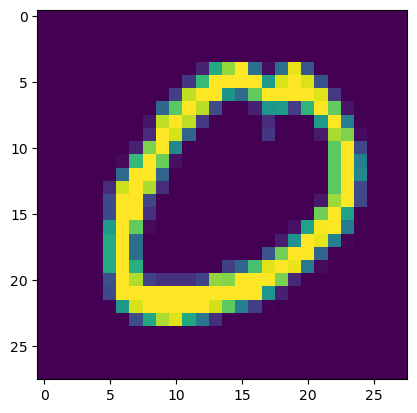

In [5]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))

In [6]:
# select a row as series
df.iloc[13051,1:]
# convert to numpy array 
df.iloc[13051,1:].to_numpy()  # or df.iloc[13051,1:].values
# then reshape in 28 by 28
df.iloc[13051,1:].to_numpy().reshape(28,28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  25,
        155, 214, 254,  93,   9,  93, 246,  68,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  41, 172,
        254, 254, 254, 254, 138, 240, 254, 241,  64,   0,   0,   0,   0,
          0,   0],
       [  

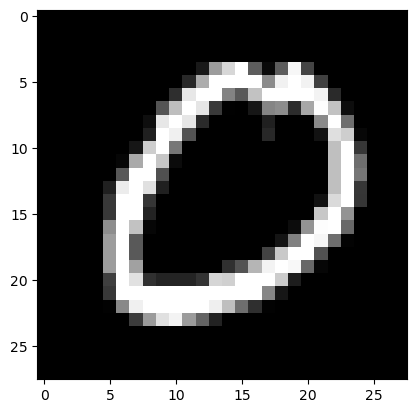

In [7]:
# df.iloc[row_no,col_no]  start from 1st column because 0th column is label answers 
plt.imshow(df.iloc[13051,1:].values.reshape(28,28),cmap='gray',)

In [8]:
px.imshow(df.iloc[13051,1:].values.reshape(28,28),binary_string=True)

In [9]:
px.imshow(df.iloc[11,1:].values.reshape(28,28),binary_string=True)

# train test split

In [3]:
X = df.iloc[:,1:] # input array as features
y = df.iloc[: ,0] # lables as target

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)

(33600, 784)
(8400, 784)


# fit KNN Model

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [14]:
y_pred = knn.predict(X_test)

# Evaulation 

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [6]:
# mean center the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# this is gadbad code
# scaling karna sa accuracy score decrease do not do it

In [18]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
33596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
33597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0
33598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.034769,-0.026785,-0.018757,-0.012827,-0.010173,-0.007711,0.0,0.0,0.0,0.0


# PCA

In [19]:
# pca
from sklearn.decomposition import PCA
pca = PCA(n_components=None)
# yadi aap n_compents none karo tho jitna columns ha utna principle compnentes ayega
# aap chaho tho ya par 100,200 columns la sakta ho 

aap na data ko naya coordinate axes par shift kar diya      

In [20]:
# X_train = pca.fit_transform(X_train)
# X_test = pca.fit_transform(X_test)

Now apka Data ek Transformed coordinate system ma ha 

In [21]:
print(X_train.shape)
print(X_test.shape)

(33600, 784)
(8400, 784)


Now take top 300 principle compents  fit and change and see shape 

In [56]:
from sklearn.decomposition import PCA
pca = PCA(n_components=300)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


print(X_train_pca.shape)
print(X_test_pca.shape)

(33600, 300)
(8400, 300)


now we have same rows but number of columns are decrease from 780 to 300

# Again Training 

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_pca,y_train)

y_pred = knn.predict(X_test_pca)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9467857142857142

In [58]:
# now make a function and change the number of pca_features and see accuracy 

def pca_features(num_of_features):
    # import librarie
    from sklearn.decomposition import PCA
    pca = PCA(n_components=num_of_features)
    
    # train fit transform and  test transform only
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)


    # shape of the model 
    print('shape of X_train' , X_train_pca.shape)
    print('shape of X_train', X_test_pca.shape)
    
    # fit and evualtion 
    knn = KNeighborsClassifier()
    knn.fit(X_train_pca,y_train)

    y_pred = knn.predict(X_test_pca)

    from sklearn.metrics import accuracy_score
    print('accuracy_score :' , accuracy_score(y_test,y_pred))

pca_features(100)

shape of X_train (33600, 100)
shape of X_train (8400, 100)
accuracy_score : 0.9544047619047619


In [59]:
# if the features is 200
pca_features(200)

shape of X_train (33600, 200)
shape of X_train (8400, 200)
accuracy_score : 0.9507142857142857


In [60]:
# 300 we see it now 500
pca_features(500)

shape of X_train (33600, 500)
shape of X_train (8400, 500)
accuracy_score : 0.9410714285714286


In [62]:
# now take all the features onces
pca_features(784)

shape of X_train (33600, 784)
shape of X_train (8400, 784)
accuracy_score : 0.9391666666666667


In [63]:
# take only the top 2 features only 
pca_features(2) 

shape of X_train (33600, 2)
shape of X_train (8400, 2)
accuracy_score : 0.3236904761904762


Accuracy is so bad in 2 dimension

In [64]:
# take only the top 3 feature
pca_features(3)

shape of X_train (33600, 3)
shape of X_train (8400, 3)
accuracy_score : 0.5104761904761905


Accuracy improve in the n dim 

In [ ]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    
    knn = KNeighborsClassifier()
    
    knn.fit(X_train_trf,y_train)
    
    y_pred = knn.predict(X_test_trf)
    
    print(accuracy_score(y_test,y_pred))

In [ ]:
for i in range(1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    
    knn = KNeighborsClassifier()
    
    knn.fit(X_train_trf,y_train)
    
    y_pred = knn.predict(X_test_trf)
    
    print(accuracy_score(y_test,y_pred))

Accuracy score it takes a lot of time 

In [ ]:
0.2580952380952381
0.3236904761904762
0.5104761904761905
0.6663095238095238
0.7378571428571429
0.8227380952380953
0.8436904761904762
0.8721428571428571
0.886547619047619
0.9055952380952381
0.9116666666666666
0.9184523809523809
0.9276190476190476
0.9351190476190476
0.9384523809523809
0.9379761904761905
0.9407142857142857
0.94
0.9425
0.9442857142857143
0.9438095238095238

0.2580952380952381
0.3236904761904762
0.5104761904761905
0.6663095238095238
0.7378571428571429
0.8227380952380953
0.8436904761904762
0.8721428571428571
0.886547619047619
0.9055952380952381
0.9116666666666666
0.9184523809523809
0.9276190476190476
0.9351190476190476
0.9384523809523809
0.9379761904761905
0.9407142857142857
0.94
0.9425
0.9442857142857143
0.9438095238095238


KeyboardInterrupt: 

In [65]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. FIT PCA ONCE GLOBALLY
max_features = 784
global_pca = PCA(n_components=max_features)

print("Fitting global PCA once...")
X_train_global_trf = global_pca.fit_transform(X_train)
X_test_global_trf = global_pca.transform(X_test)


# 2. OPTIMIZED FUNCTION
def evaluate_pca_features(num_of_features, X_train_full, X_test_full, y_train, y_test):
    # Slice the pre-computed PCA features instantly using NumPy
    X_train_pca = X_train_full[:, :num_of_features]
    X_test_pca = X_test_full[:, :num_of_features]

    # Fit and evaluation (n_jobs=-1 speeds up KNN processing)
    knn = KNeighborsClassifier(n_jobs=-1)
    knn.fit(X_train_pca, y_train)

    y_pred = knn.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    
    return acc


# 3. GENERATE TARGETS AND LOOP
# Testing a sequence of feature steps (e.g., 50, 100, 150... up to 750)
feature_counts = np.arange(50, max_features, 50)
accuracies = np.zeros_like(feature_counts, dtype=float)

print("Evaluating feature subsets...")
for idx, num in np.ndenumerate(feature_counts):
    accuracies[idx] = evaluate_pca_features(
        num_of_features=num, 
        X_train_full=X_train_global_trf, 
        X_test_full=X_test_global_trf, 
        y_train=y_train, 
        y_test=y_test
    )

# 4. STORE RESULTS INTO A PANDAS DATAFRAME
results_df = pd.DataFrame({
    'Number_of_Components': feature_counts,
    'Accuracy_Score': accuracies
})

# Display the final DataFrame
print("\n--- Final Performance Results ---")
print(results_df)


Fitting global PCA once...
Evaluating feature subsets...

--- Final Performance Results ---
    Number_of_Components  Accuracy_Score
0                     50        0.953333
1                    100        0.954405
2                    150        0.952024
3                    200        0.950714
4                    250        0.948571
5                    300        0.946786
6                    350        0.944643
7                    400        0.943690
8                    450        0.942262
9                    500        0.941071
10                   550        0.940476
11                   600        0.939643
12                   650        0.939881
13                   700        0.939167
14                   750        0.939167


In [66]:
results_df

,Number_of_Components,Accuracy_Score
0,50,0.953333
1,100,0.954405
2,150,0.952024
3,200,0.950714
4,250,0.948571
5,300,0.946786
6,350,0.944643
7,400,0.943690
8,450,0.942262
9,500,0.941071


In [69]:
px.line(
    data_frame=results_df,
    x = results_df['Number_of_Components'],
    y = results_df['Accuracy_Score']
)

Relationship between as  Number of principle compents increase what happen to accruacy score . 
it is cloased range between 94 to 95

In [70]:
print('min :' ,results_df['Accuracy_Score'].min() )
print('max :' ,results_df['Accuracy_Score'].max() )
print('range :', results_df['Accuracy_Score'].max() - results_df['Accuracy_Score'].min())

min : 0.9391666666666667
max : 0.9544047619047619
range : 0.015238095238095162


So accuracy score is still same in the all principle components 

# Visulisations of pca

## 2d

In [35]:
# transforming to a 2d coordinate space
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [36]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

In [37]:

y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                y=X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

## 3d

In [8]:
from sklearn.decomposition import PCA

In [9]:
# transforming to a 3d coordinate space
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [10]:
X_test_trf

array([[-5.00669776, -2.63019775,  2.70940772],
       [-7.75779783, -1.47422566,  2.83173459],
       [-7.47285122,  1.61830189, -5.40351285],
       ...,
       [ 2.40771554, -1.55006574,  8.98506077],
       [10.55730625, -2.46747756, -6.50195018],
       [-3.42369586,  5.09417156, -1.05542261]])

In [11]:

fig = px.scatter_3d(data_frame=X,
                    x=X_train_trf[:,0],
                    y=X_train_trf[:,1], 
                    z=X_train_trf[:,2],
            color=y_train.astype(str))
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()


Green = 3 and yellow = 2 overlap so much        
Green = 3 and Blue = 8 overlap so much        


important attribuites in the pca

In [76]:
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

This explained_variance_ is actually Eigenvalue 

In [79]:
pd.DataFrame(pca.components_)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.000978,0.000138,0.000722,0.000995,0.001065,0.001019,0.0,0.0,0.0,0.0
1,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,0.017970,0.015032,0.010407,0.007119,0.004605,0.003328,-0.0,-0.0,-0.0,-0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.008631,-0.006327,-0.003950,-0.002142,-0.001309,-0.000830,0.0,0.0,0.0,0.0


In [77]:
pca.components_.shape

(3, 784)

In [12]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

Meaning              
first  principle compenent 5%           
first  principle compenent 4%               
first  principle compenent 3%                         

so their are 3 vectors 784 dimensions 

In [15]:
# now fit pca to all compenet 
# now make a function and change the number of pca_features and see accuracy 

# import librarie
from sklearn.decomposition import PCA
pca = PCA(n_components=None)

# train fit transform and  test transform only
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# shape of the model 
print('shape of X_train' , X_train_pca.shape)
print('shape of X_train', X_test_pca.shape)

# fit and evualtion 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_pca,y_train)

y_pred = knn.predict(X_test_pca)

from sklearn.metrics import accuracy_score
print('accuracy_score :' , accuracy_score(y_test,y_pred))



shape of X_train (33600, 784)
shape of X_train (8400, 784)
accuracy_score : 0.9391666666666667


In [45]:
# shape of eigenvector
pca.components_.shape

(784, 784)

In [18]:
# now find the explained varience ratio
# percentage contribution of each principle compenet 
print(pca.explained_variance_ratio_)

[5.78519225e-02 4.14926968e-02 3.80423901e-02 2.96626277e-02
 2.58156168e-02 2.25498018e-02 1.97306802e-02 1.77527998e-02
 1.56865066e-02 1.43606328e-02 1.37025484e-02 1.22725500e-02
 1.14691200e-02 1.12302739e-02 1.05852885e-02 1.01993106e-02
 9.57676152e-03 9.42708817e-03 9.12489429e-03 8.90170190e-03
 8.39940495e-03 8.20063196e-03 7.85303229e-03 7.56739707e-03
 7.37261022e-03 7.01884653e-03 6.97919728e-03 6.71104483e-03
 6.39845030e-03 6.30337291e-03 6.15350848e-03 6.02388659e-03
 5.83673972e-03 5.78547759e-03 5.72333148e-03 5.46399774e-03
 5.43207369e-03 5.28172755e-03 5.13381744e-03 4.94015474e-03
 4.87671103e-03 4.81978768e-03 4.68204430e-03 4.59342487e-03
 4.57660834e-03 4.49219022e-03 4.44682221e-03 4.41540749e-03
 4.35111936e-03 4.32032928e-03 4.21808870e-03 4.18243127e-03
 4.07994349e-03 4.02004913e-03 3.98335855e-03 3.94598812e-03
 3.86871612e-03 3.83195184e-03 3.76552618e-03 3.74193467e-03
 3.64852155e-03 3.60802540e-03 3.53886455e-03 3.47941353e-03
 3.44323418e-03 3.379375

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

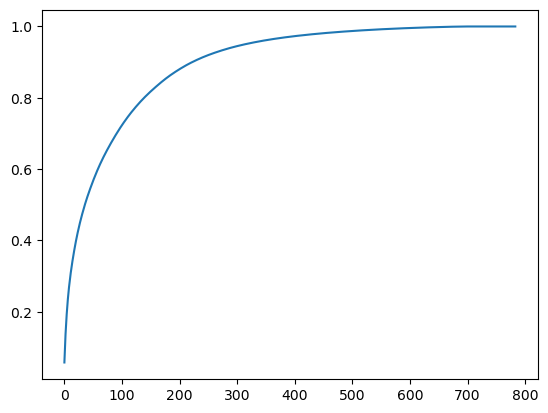

In [22]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [23]:
px.line(np.cumsum(pca.explained_variance_ratio_))

In [43]:
# how many number of components needed that explain the 90 percent varience 
principle_components = pd.Series(np.cumsum(pca.explained_variance_ratio_))
result = principle_components[principle_components <= 0.9012]
result

0      0.057852
1      0.099345
2      0.137387
3      0.167050
4      0.192865
         ...   
219    0.897689
220    0.898508
221    0.899323
222    0.900132
223    0.900936
Length: 224, dtype: float64

In [44]:
result.iloc[-1]

0.9009359563002628

So we need the 224 optimual number that explain the 90% varience in the 784 cols data 